<a href="https://colab.research.google.com/github/prakhar362/MLDL-Lab/blob/main/PS_mldl_exp10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

Unzip Dataset

In [ ]:
import zipfile

zip_path = "/content/sample_data/seg_pred.zip"
extract_path = "/content/intel_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed")

Extraction completed


In [ ]:
import os
os.listdir('/content/sample_data')

['anscombe.json',
 'README.md',
 'seg_pred.zip',
 'california_housing_train.csv',
 'mnist_train_small.csv',
 'california_housing_test.csv',
 'mnist_test.csv']

In [ ]:
import os
os.listdir('/content/intel_data')

['seg_pred']

Load Images

In [ ]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

img_size = 128
path = "/content/intel_data/seg_pred"   # change if needed

images = []

for file in os.listdir(path):
    file_path = os.path.join(path, file)

    if file.lower().endswith(('.jpg', '.png', '.jpeg')):
        img = load_img(file_path, target_size=(img_size, img_size))
        img = img_to_array(img) / 255.0
        images.append(img)

images = np.array(images)

print("Loaded images shape:", images.shape)

Loaded images shape: (7301, 128, 128, 3)


Add Noise to Images

In [ ]:
noise_factor = 0.3

noisy_images = images + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=images.shape)

noisy_images = np.clip(noisy_images, 0., 1.)

print("Noisy images shape:", noisy_images.shape)

Noisy images shape: (7301, 128, 128, 3)


Build Convolutional Autoencoder Model

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

input_img = keras.Input(shape=(128, 128, 3))

# 🔹 Encoder
x = layers.Conv2D(32, 3, activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D(2, padding='same')(x)

# 🔹 Decoder
x = layers.Conv2D(64, 3, activation='relu', padding='same')(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

decoded = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [ ]:
history = autoencoder.fit(
    noisy_images,
    images,        # clean images as target
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 476s 3s/step - loss: 0.0202 - val_loss: 0.0144
Epoch 2/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 490s 3s/step - loss: 0.0133 - val_loss: 0.0126
Epoch 3/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 471s 3s/step - loss: 0.0125 - val_loss: 0.0120
Epoch 4/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 489s 3s/step - loss: 0.0120 - val_loss: 0.0119
Epoch 5/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 469s 3s/step - loss: 0.0115 - val_loss: 0.0113
Epoch 6/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 465s 3s/step - loss: 0.0113 - val_loss: 0.0110
Epoch 7/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 515s 3s/step - loss: 0.0111 - val_loss: 0.0108
Epoch 8/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 505s 3s/step - loss: 0.0109 - val_loss: 0.0107
Epoch 9/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 472s 3s/step - loss: 0.0108 - val_loss: 0.0105
Epoch 10/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 493s 3s/step - loss: 0.0106 - val_loss: 0.0103


Generate Denoised Images

In [ ]:
denoised = autoencoder.predict(noisy_images[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step


Visualize Results (VERY IMPORTANT)

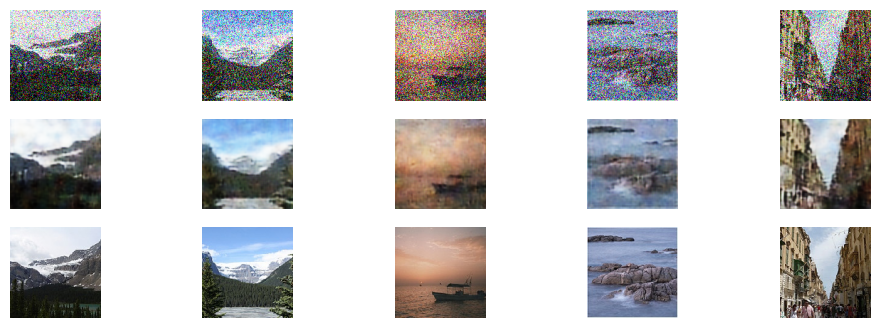

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

for i in range(5):

    # 🔹 Noisy image
    ax = plt.subplot(3,5,i+1)
    plt.imshow(noisy_images[i])
    plt.axis("off")

    # 🔹 Denoised image
    ax = plt.subplot(3,5,i+6)
    plt.imshow(denoised[i])
    plt.axis("off")

    # 🔹 Original image
    ax = plt.subplot(3,5,i+11)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()